# Chapter 5: Getting Started with pandas

- While pandas adopts many coding idioms from NumPy, the biggest difference is that **pandas** is designed for working with **tabular or heterogeneous data**. **NumPy**, by contrast, is best suited for working with **homogeneous numerical array data**.

## 5.1 Introduction to pandas Data Structure

### Series

In [1]:
import numpy as np
import pandas as pd
from pandas import DataFrame, Series

In [5]:
# List로 Series 선언
obj = pd.Series([4, 7, -5, 3], index=['d','b','a','c'])

In [6]:
obj.values

array([ 4,  7, -5,  3])

In [7]:
obj.index

Index(['d', 'b', 'a', 'c'], dtype='object')

In [8]:
obj2['a']

-5

In [9]:
obj2['d'] = 6
obj2

d    6
b    7
a   -5
c    3
dtype: int64

In [10]:
obj2[['c', 'a', 'd']] 

c    3
a   -5
d    6
dtype: int64

- Using NumPy functions or NumPy-like operations, such as filtering with a boolean array, scalar multiplication, or applying math functions, will preserve the index-value link:

In [11]:
obj2[obj2>0]

d    6
b    7
c    3
dtype: int64

In [12]:
obj2*2

d    12
b    14
a   -10
c     6
dtype: int64

In [15]:
np.exp(obj2)

d     403.428793
b    1096.633158
a       0.006738
c      20.085537
dtype: float64

- data contained in a Python dict, you can create a Series from it by passing the dict:

In [8]:
# Dict로 Series 선언
sdata = {'Ohio':35000, 'Texas':71000, 'Oregon':16000, 'Utah':5000}
obj3 = pd.Series(sdata)
obj3

Ohio      35000
Texas     71000
Oregon    16000
Utah       5000
dtype: int64

In [17]:
states = ['California', 'Ohio', 'Oregon', 'Texas']
obj4 = pd.Series(sdata, index=states)
obj4

California        NaN
Ohio          35000.0
Oregon        16000.0
Texas         71000.0
dtype: float64

- The ***isnull*** and ***notnull*** functions in pandas should be used to detect missing data:
- Series also has these as **instance methods**:

In [23]:
pd.isnull(obj4) # obj4.isnull()

California     True
Ohio          False
Oregon        False
Texas         False
dtype: bool

In [22]:
pd.notnull(obj4)

California    False
Ohio           True
Oregon         True
Texas          True
dtype: bool

- A useful Series feature for many applications is that it automatically aligns by index label in arithmetic operations:

In [24]:
obj3 + obj4

California         NaN
Ohio           70000.0
Oregon         32000.0
Texas         142000.0
Utah               NaN
dtype: float64

- Both the Series object itself and its index have a name attribute, which integrates with other key areas of pandas functionality:

In [25]:
obj4.name = 'population'
obj4.index.name = 'state'
obj4

state
California        NaN
Ohio          35000.0
Oregon        16000.0
Texas         71000.0
Name: population, dtype: float64

In [27]:
# A Series's index can be altered in-place by assignment:
obj.index = ['Bob', 'Steve', 'Jeff', 'Ryan']
obj

Bob      4
Steve    7
Jeff    -5
Ryan     3
dtype: int64

### DataFrame

- There are many ways to construct a DataFrame, though one of the most common is **from a dict of equal-length lists or NumPy arrays**:

In [10]:
data = {'state': ['Ohio', 'Ohio', 'Ohio', 'Nevada', 'Nevada', 'Nevada'],
       'year': [2000, 2001, 2002, 2001, 2002, 2003],
       'pop': [1.5, 1.7, 3.6, 2.4, 2.9, 3.2]}
frame = pd.DataFrame(data)
frame

,state,year,pop
0,Ohio,2000,1.5
1,Ohio,2001,1.7
2,Ohio,2002,3.6
3,Nevada,2001,2.4
4,Nevada,2002,2.9
5,Nevada,2003,3.2


- If you specify a sequence of columns, the DataFrame’s columns will be arranged in that order:

In [11]:
frame2 = pd.DataFrame(data, columns=['year', 'state', 'pop', 'debt'],
                     index=['one', 'two', 'three', 'four', 'five', 'six'])
frame2

,year,state,pop,debt
one,2000,Ohio,1.5,NaN
two,2001,Ohio,1.7,NaN
three,2002,Ohio,3.6,NaN
four,2001,Nevada,2.4,NaN
five,2002,Nevada,2.9,NaN
six,2003,Nevada,3.2,NaN


- A column in a DataFrame can be retrieved as a Series either by dict-like notation or by attribute:
- Attribute-like access (e.g., frame2.year) and tab completion of column names in IPython is provided as a convenience. 
- ***frame2[column]*** works for any column name, but ***frame2.column*** only works when the column name is a valid Python variable name.

In [12]:
frame2['state'] #frame2.state

one        Ohio
two        Ohio
three      Ohio
four     Nevada
five     Nevada
six      Nevada
Name: state, dtype: object

In [13]:
frame2.year #frame2['year']

one      2000
two      2001
three    2002
four     2001
five     2002
six      2003
Name: year, dtype: int64

- Note that the returned Series have the same index as the DataFrame, and their ***name*** attribute has been appropriately set.
- When you are **assigning lists or array** to a column, the value's length must **match the length of the DataFrame**. If you **assign a Series**, its **labels will be realigned exactly to the DataFrame's index**, inserting missing values in any holes:

In [17]:
# list assign 
frame2['debt'] = np.arange(6) #Column 이름 접근
frame2

,year,state,pop,debt
one,2000,Ohio,1.5,0
two,2001,Ohio,1.7,1
three,2002,Ohio,3.6,2
four,2001,Nevada,2.4,3
five,2002,Nevada,2.9,4
six,2003,Nevada,3.2,5


In [15]:
# Series assign
val = pd.Series([-1.2, -1.5, -1.7], index=['two', 'four', 'five'])
frame2.debt = val #Attribute 접근
frame2

,year,state,pop,debt
one,2000,Ohio,1.5,NaN
two,2001,Ohio,1.7,-1.2
three,2002,Ohio,3.6,NaN
four,2001,Nevada,2.4,-1.5
five,2002,Nevada,2.9,-1.7
six,2003,Nevada,3.2,NaN


- **The column returned from indexing a DataFrame is a view on the underlying data, not a copy**. Thus, any in-place modifications to the Series will be reflected in the DataFrame. The column can be explicitly copied with the Series’s ***copy*** method

- If the nested dict is passed to the DataFrame, pandas will interpret **the outer dict keys as the columns** and **the inner keys as the row indices**:

In [21]:
# Dict of dicts
pop = {'Nevada': {2001:2.4, 2002:2.9},
      'Ohio': {2000:1.5, 2001:1.7, 2002:3.6}}

In [22]:
frame3 = pd.DataFrame(pop, index=[2000, 2001, 2002])
frame3

,Nevada,Ohio
2000,NaN,1.5
2001,2.4,1.7
2002,2.9,3.6


In [23]:
frame3.T

,2000,2001,2002
Nevada,NaN,2.4,2.9
Ohio,1.5,1.7,3.6


In [24]:
# Dicts of Series are treated in much the same way:
pdata = {'Ohio': frame3['Ohio'][:-1],
        'Nevada': frame3['Nevada'][:2]}
pd.DataFrame(pdata, columns = ['Nevada', 'Ohio' ])

,Nevada,Ohio
2000,NaN,1.5
2001,2.4,1.7


> 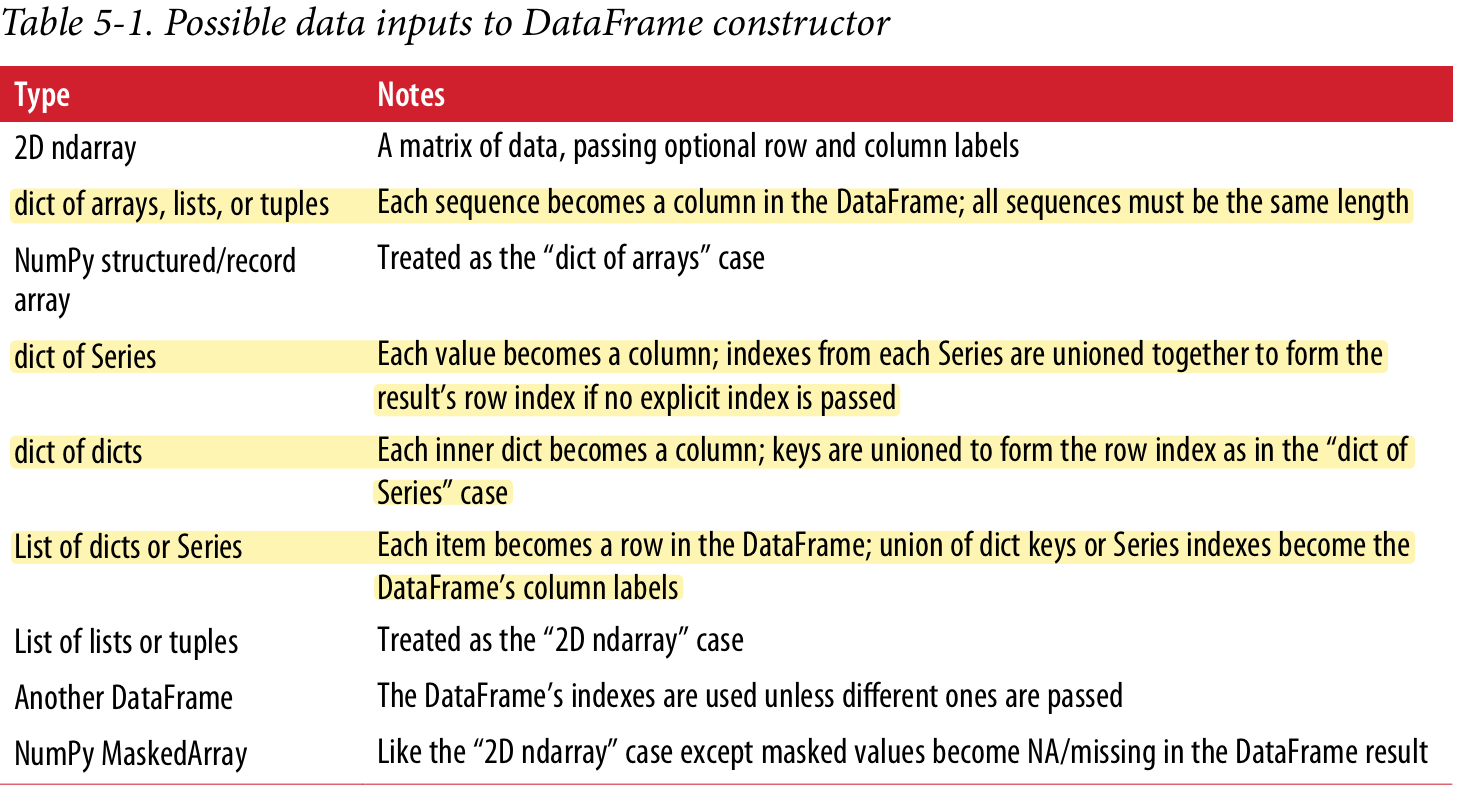

### Index Objects

- Index objects are **immutable** and thus can’t be modified by the user
- An Index also behaves like a **fixed-size set**
- Unlike Python sets, a pandas Index **can contain duplicate labels**

In [25]:
frame3

,Nevada,Ohio
2000,NaN,1.5
2001,2.4,1.7
2002,2.9,3.6


In [26]:
frame3.columns.name = 'state'
frame3.columns

Index(['Nevada', 'Ohio'], dtype='object', name='state')

In [27]:
'Ohio' in frame3.columns

True

In [30]:
2003 in frame3.index # Attribute 접근시 index 소문자 사용

False

In [31]:
# Method 형태로 접근시 Index 대문자임을 주의 
dup_labels = pd.Index(['foo', 'foo', 'bar', 'bar']) # 중복항 가능함
dup_labels

Index(['foo', 'foo', 'bar', 'bar'], dtype='object')

> 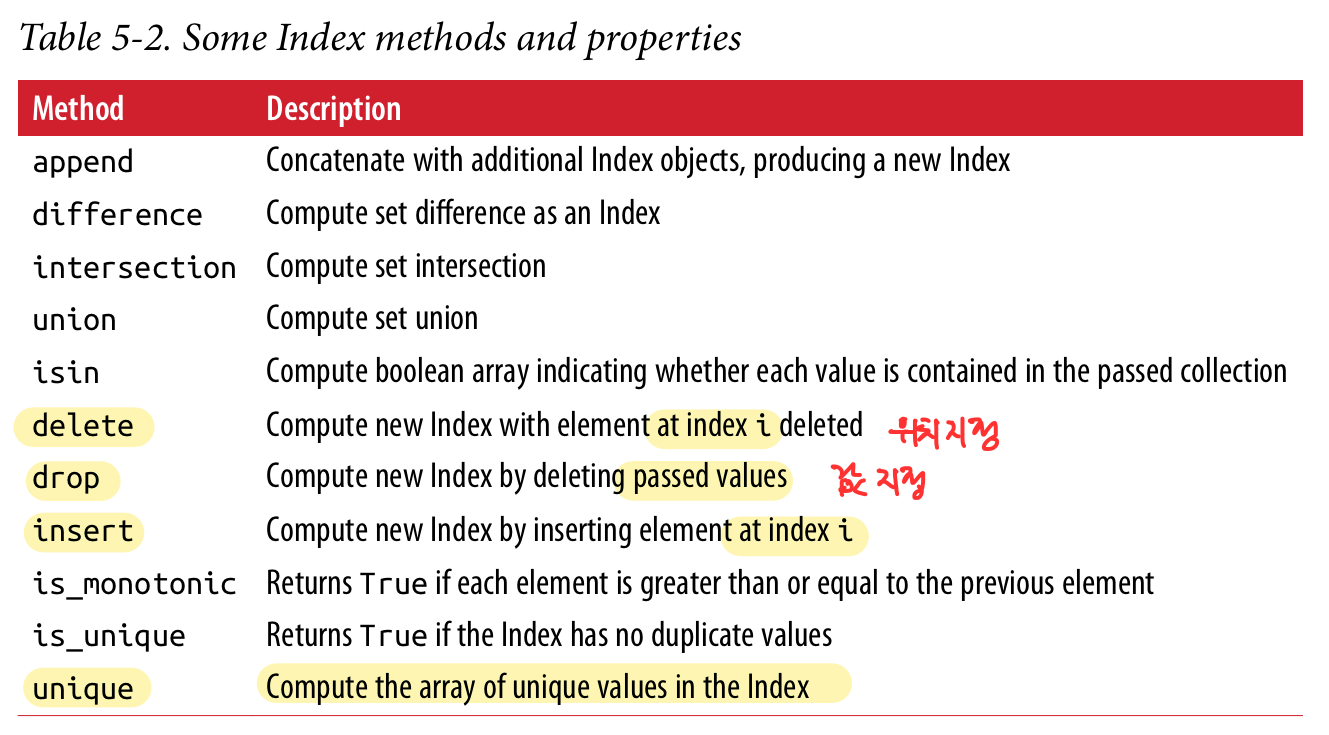

In [43]:
frame3.index.append(pd.Index([20]))

Int64Index([2000, 2001, 2002, 20], dtype='int64')

## 5.2 Essential Functionality

### Reindexing

In [117]:
obj = pd.Series([4.5, 7.2, -5.3, 3.6], index=['d', 'b', 'a', 'c'])
obj

d    4.5
b    7.2
a   -5.3
c    3.6
dtype: float64

- Calling reindex on this Series **rearranges the data** according to the new index, **introducing missing values** if any index values were **not already present**:

In [118]:
obj2 = obj.reindex(['a', 'b', 'c', 'd', 'e'])
obj2

a   -5.3
b    7.2
c    3.6
d    4.5
e    NaN
dtype: float64

- For ordered data like time series, it may be desirable to do some **interpolation or filling of values** when reindexing. The method option allows us to do this, using a method such as ***ffill***, which **forward-fills the values**:

In [2]:
obj3 = pd.Series(['blue', 'purple', 'yellow'], index=[0, 2, 4])
obj3

0      blue
2    purple
4    yellow
dtype: object

In [3]:
obj3.reindex(range(6), method='ffill')

0      blue
1      blue
2    purple
3    purple
4    yellow
5    yellow
dtype: object

#### **예시**) 행 추가 + 행 순서 변경 + 열 추가 및 선택 

In [44]:
frame = pd.DataFrame(np.arange(9).reshape((3,3)),
                     index=['a', 'c', 'd'],
                     columns=['Ohio', 'Texas', 'California'])

states = ['Texas', 'Utah', 'California']

frame

,Ohio,Texas,California
a,0,1,2
c,3,4,5
d,6,7,8


In [45]:
# 방법_1 : reindex 사용
frame2 = frame.reindex(['a', 'b', 'c', 'd']) # b행 추가 및 행순서 변경
frame2

,Ohio,Texas,California
a,0.0,1.0,2.0
b,NaN,NaN,NaN
c,3.0,4.0,5.0
d,6.0,7.0,8.0


In [46]:
frame3 = frame2.reindex(columns = states) # Utah열 추가 Ohio 열제거, 열순서변경
frame3

,Texas,Utah,California
a,1.0,NaN,2.0
b,NaN,NaN,NaN
c,4.0,NaN,5.0
d,7.0,NaN,8.0


In [47]:
# 방법_2 : label-indexing with loc
frame.loc[['a', 'b', 'c', 'd'], states] #교재에서는 가능

KeyError: "['b'] not in index"

### Droping Entries from an Axis

- **Calling drop with a sequence of labels will drop values from the row labels (axis 0)**:
- Drop values from the columns by passing **axis=1 or axis='columns'**:
- Many functions, like drop, which modify the size or shape of a Series or DataFrame, can **manipulate an object *in-place* without returning a new object**:

In [17]:
data = pd.DataFrame(np.arange(16).reshape((4, 4)),
                    index=['Ohio', 'Colorado', 'Utah', 'New York'],
                    columns=['one', 'two', 'three', 'four'])
data

,one,two,three,four
Ohio,0,1,2,3
Colorado,4,5,6,7
Utah,8,9,10,11
New York,12,13,14,15


In [10]:
# 행 drop
data.drop(['Colorado', 'Ohio']) #data 변경은 없음-> 새변수 할당 필요

,one,two,three,four
Utah,8,9,10,11
New York,12,13,14,15


In [11]:
# 열 drop
data.drop(['two', 'four'], axis=1) #or axis='columns'

,one,three
Ohio,0,2
Colorado,4,6
Utah,8,10
New York,12,14


In [18]:
# inplace 조건
data.drop(['New York'], inplace=True)
data #원 데이터프레임 자체가 변경, 주의 필요

,one,two,three,four
Ohio,0,1,2,3
Colorado,4,5,6,7
Utah,8,9,10,11


### Indexing, Selection, and Filtering

- Slicing with labels behaves differently than normal Python slicing in that **the end‐point is inclusive**

### Series (기본 행 접근)

In [43]:
obj = pd.Series(np.arange(4.), index=['a', 'b', 'c', 'd'])
obj

a    0.0
b    1.0
c    2.0
d    3.0
dtype: float64

- #### 단독 색인

```python
obj['b'] = obj[1] #레이블, 정수 모두 가능
```
- #### Fancy 색인

```python
obj[['b', 'd']] = obj[[1, 3]] #레이블, 정수 모두 가능
```
- #### Slicing 색인

```python
obj['b' : 'c'] = obj[1 : 3] #레이블로 슬라이싱 시 end도 포함
```

### DataFrame (기본 열 접근)

In [50]:
data = pd.DataFrame(np.arange(16).reshape((4,4)),
                   index=['Ohio', 'Colorado', 'Utah', 'New York'],
                   columns=['one', 'two', 'three', 'four'])
data

,one,two,three,four
Ohio,0,1,2,3
Colorado,4,5,6,7
Utah,8,9,10,11
New York,12,13,14,15


- #### 단독 색인
```python
data['two'] #-> 열 접근, 레이블만 가능
```
> 단독 색인으로 레이블+정수 모두 행 접근 불가함

- #### Fancy 색인
```python
data[['three', 'one']] #-> 열 접근, 레이블만 가능
```
> Fancy 색인으로 레이블+정수 모두 행 접근 불가함

- #### Silicing 색인 -> 행 접근
```python
data['Utah':'New York'] = data[2:4] #-> 행 접근
```
> Slicing 색인으로 레이블+정수 모두 열 접근 불가함

- #### 행에 대한 접근을 위해 loc(레이블), iloc(정수) 도입
```python
data.loc['Colorado', ['two','three']]
data.iloc[1, [1, 2]]
data.iloc[2] #-> 단독 행 접근
```
> loc와 iloc에 대한 슬라이승 기법 사용 가능
>```python
data.loc[:'Utah', 'two']
Ohio			1
Colorado		5
Utah			9
#-------------------------------------
data.iloc[:, :3][data.three > 5]
			One		two		three
Colorado    4         5         6	
Utah		8         9         10
New York	12		13		14
```

### Integer Indexes (주의)
- To keep things consistent, if you have an **axis index containing integer**, data selection will always be **label-oriented**
- For more precise handling, use ***loc(레이블)*** or ***iloc(정수)***

In [3]:
ser = pd.Series(np.arange(3.))
ser

0    0.0
1    1.0
2    2.0
dtype: float64

In [7]:
ser[:1] #-> 정수로 인정하여 1 미포함

0    0.0
dtype: float64

In [8]:
ser.loc[:1] #-> 레이블로 인정하여 1포함

0    0.0
1    1.0
dtype: float64

In [9]:
ser.iloc[:1] #-> 정수로 인정하여 1마포함

0    0.0
dtype: float64

### Arithmetic and Data Alignment
- When you are adding together objects, if any index pairs are not the same, the respective index in the result will be **the union of the index pairs**. For users with database experience, this is similar to an automatic outer join on the index labels.

In [8]:
df1 = pd.DataFrame(np.arange(9.).reshape((3,3)),
                  columns=list('bcd'), index=['Ohio', 'Texas','Colorado'])
df2 = pd.DataFrame(np.arange(12.).reshape((4,3)), columns=list('bde'),
                  index=['Utah', 'Ohio', 'Texas', 'Oregon'])
print(df1)
print(df2)

            b    c    d
Ohio      0.0  1.0  2.0
Texas     3.0  4.0  5.0
Colorado  6.0  7.0  8.0
          b     d     e
Utah    0.0   1.0   2.0
Ohio    3.0   4.0   5.0
Texas   6.0   7.0   8.0
Oregon  9.0  10.0  11.0


In [9]:
df1 + df2

,b,c,d,e
Colorado,NaN,NaN,NaN,NaN
Ohio,3.0,NaN,6.0,NaN
Oregon,NaN,NaN,NaN,NaN
Texas,9.0,NaN,12.0,NaN
Utah,NaN,NaN,NaN,NaN


- Since the 'c' and 'e' columns are not found in both DataFrame objects, they appear as all missing in the result. The same holds for the rows whose labels are not common to both objects.

#### Arithmetic methods with fill values
- Using the add method on df1, and an argument to ***fill_value***:
- List of Series and DataFrame methods for arithmetic
    - add(+), sub(-), div(/)
    - floordiv(//), mul(\*), pow(\**)
    - Each of them has a counterpart, starting with the letter r, that has arguments flipped. ex) radd, rdiv, rpow

In [11]:
df1.add(df2, fill_value=0)

,b,c,d,e
Colorado,6.0,7.0,8.0,NaN
Ohio,3.0,1.0,6.0,5.0
Oregon,9.0,NaN,10.0,11.0
Texas,9.0,4.0,12.0,8.0
Utah,0.0,NaN,1.0,2.0


#### Operations between DataFrame and Series
- Operations between a DataFrame and a Series are similar to NumPy arrays: (***Broadcasting***)

In [2]:
frame =  pd.DataFrame(np.arange(12.).reshape((4,3)),
                     columns=list('bde'),
                     index=['Utah','Ohio','Texas','Oregon'])
series = frame.iloc[0]
print(frame)
print(series)

          b     d     e
Utah    0.0   1.0   2.0
Ohio    3.0   4.0   5.0
Texas   6.0   7.0   8.0
Oregon  9.0  10.0  11.0
b    0.0
d    1.0
e    2.0
Name: Utah, dtype: float64


- By default, arithmetic between DataFrame and Series **matches the index of the Series on the DataFrame’s columns**, broadcasting down the rows

In [3]:
frame - series

,b,d,e
Utah,0.0,0.0,0.0
Ohio,3.0,3.0,3.0
Texas,6.0,6.0,6.0
Oregon,9.0,9.0,9.0


- If an index value is not found in either the DataFrame's columns or the Series's index, the objects will be reindexed to form the union:

In [4]:
series2 = pd.Series(range(3), index=['b', 'e', 'f'])
frame + series2

,b,d,e,f
Utah,0.0,NaN,3.0,NaN
Ohio,3.0,NaN,6.0,NaN
Texas,6.0,NaN,9.0,NaN
Oregon,9.0,NaN,12.0,NaN


- **If you want to instead broadcast over the columns, matching on the rows, you have to use one of the arithmetic method**:

In [5]:
series3 = frame['d']

In [6]:
frame.sub(series3, axis='index')

,b,d,e
Utah,-1.0,0.0,1.0
Ohio,-1.0,0.0,1.0
Texas,-1.0,0.0,1.0
Oregon,-1.0,0.0,1.0


### Function Application and Mapping
- NumPy ufuncs(element-wise array method) also work with pandas objects:

In [8]:
frame = pd.DataFrame(np.random.randn(4,3), columns=list('bde'),
                    index=['Utah','Ohio','Texas','Oregon'])
frame

,b,d,e
Utah,0.427919,0.482504,1.186852
Ohio,-0.645449,0.463612,-0.558274
Texas,-0.064517,-1.320542,0.077825
Oregon,-0.329628,-1.399807,-0.282756


In [13]:
np.abs(frame) # 보여주기만 바뀜, 원본 변화 x

,b,d,e
Utah,0.427919,0.482504,1.186852
Ohio,0.645449,0.463612,0.558274
Texas,0.064517,1.320542,0.077825
Oregon,0.329628,1.399807,0.282756


- Another frequent operation is **applying a function on one-dimenstional arrays to each column or row** :

In [15]:
f = lambda x: x.max() - x.min()
frame.apply(f)

b    1.073369
d    1.882311
e    1.745126
dtype: float64

- applied once on **each column in *frame***. The result is a Series having **the columns of *frame* as its index**
- If you pass ***axis = 'columns'*** to apply, the function will be invoked ***once per row*** instead: 
- The function passed to *apply* need not return a scalar value; it can also return a Series with multiple values:

In [21]:
def f(x):
    return pd.Series([x.min(), x.max()], index=['min', 'max'])

In [22]:
frame.apply(f)

,b,d,e
min,-0.645449,-1.399807,-0.558274
max,0.427919,0.482504,1.186852


In [23]:
frame.apply(f, axis='columns')

,min,max
Utah,0.427919,1.186852
Ohio,-0.645449,0.463612
Texas,-1.320542,0.077825
Oregon,-1.399807,-0.282756


- for Series, ***map***
- for DataFrame, ***applymap***

In [25]:
format = lambda x: '%.2f' %x

In [26]:
# Series
frame['e'].map(format)

Utah       1.19
Ohio      -0.56
Texas      0.08
Oregon    -0.28
Name: e, dtype: object

In [27]:
# DataFrame
frame.applymap(format)

,b,d,e
Utah,0.43,0.48,1.19
Ohio,-0.65,0.46,-0.56
Texas,-0.06,-1.32,0.08
Oregon,-0.33,-1.40,-0.28


### Sorting and Ranking
- To sort lexicographically by row or column index, use the ***sort_index*** method, which returns a new, sorted object

In [5]:
frame = pd.DataFrame(np.arange(8).reshape((2,4)),
                    index=['three', 'one'],
                    columns=['d','a','b','c'])
frame2 = frame.sort_index()
frame2

,d,a,b,c
one,4,5,6,7
three,0,1,2,3


In [6]:
frame2.sort_index(axis=1, ascending=False)

,d,c,b,a
one,4,7,6,5
three,0,3,2,1


- To sort **a Series** by its values, use its ***sort_values*** method
- Any missing valuse are sorted to the end of the Series by default

In [7]:
obj = pd.Series([4, np.nan, 7, np.nan, -3, 2])
obj.sort_values()

4   -3.0
5    2.0
0    4.0
2    7.0
1    NaN
3    NaN
dtype: float64

- When sorting a DataFrame, you can use the data in **one or more columns as the sort keys**. To do so, pass one or more column names to the **by option of *sort_values***:

In [15]:
frame = pd.DataFrame({'b':[4,7,-3,2], 'a':[0,1,0,1]})
frame.sort_values(by='b')

,b,a
2,-3,0
3,2,1
0,4,0
1,7,1


In [12]:
frame.sort_values(by=['a','b'])

,b,a
2,-3,0
0,4,0
3,2,1
1,7,1


- Ranking assigns ranks from one through the number of valid data points in an array.  The rank methods for Series and DataFrame are the place to look; **by default rank breaks ties by assigning each group the mean rank**:

>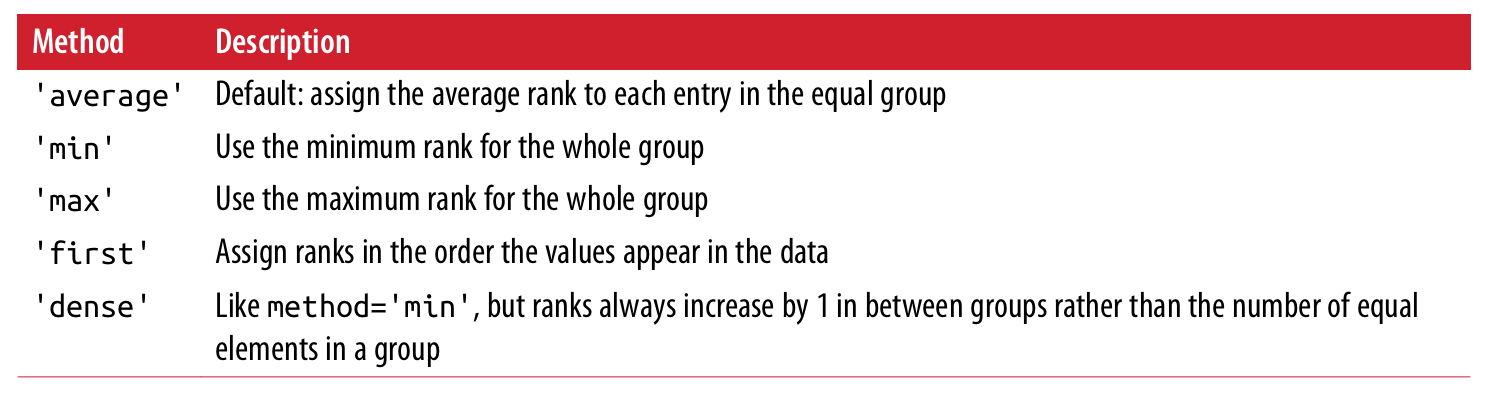

In [2]:
obj = pd.Series([7,-5,7,4,2,0,4])
obj.rank() # method='first' or 'max' or 'min'...

0    6.5
1    1.0
2    6.5
3    4.5
4    3.0
5    2.0
6    4.5
dtype: float64

In [18]:
frame = pd.DataFrame({'a':[0,1,0,1], 'b':[4.3,7,-3,2], 'c':[-2,5,8,-2.5]})
frame

,a,b,c
0,0,4.3,-2.0
1,1,7.0,5.0
2,0,-3.0,8.0
3,1,2.0,-2.5


In [17]:
frame.rank(axis='columns')

,a,b,c
0,2.0,3.0,1.0
1,1.0,3.0,2.0
2,2.0,1.0,3.0
3,2.0,3.0,1.0


### Axis Indexes with Duplicate Labels
- The index’s ***is_unique*** property can tell you whether its labels are unique or not:

In [4]:
obj = pd.Series(range(5), index=['a','a','b','b','c'])
df = pd.DataFrame(np.random.randn(4,3), index=['a','a','b','b'])

In [3]:
obj['a'] # 중복: series -> series

a    0
a    1
dtype: int64

In [4]:
obj['c'] # 단독: series -> scalar

4

In [5]:
df.loc['a'] # 중복: df -> df

,0,1,2
a,1.260188,-0.565595,-0.152344
a,-0.052065,-0.481060,-0.415224


## 5.3 Summarizing and Computing Descriptive Statics
> 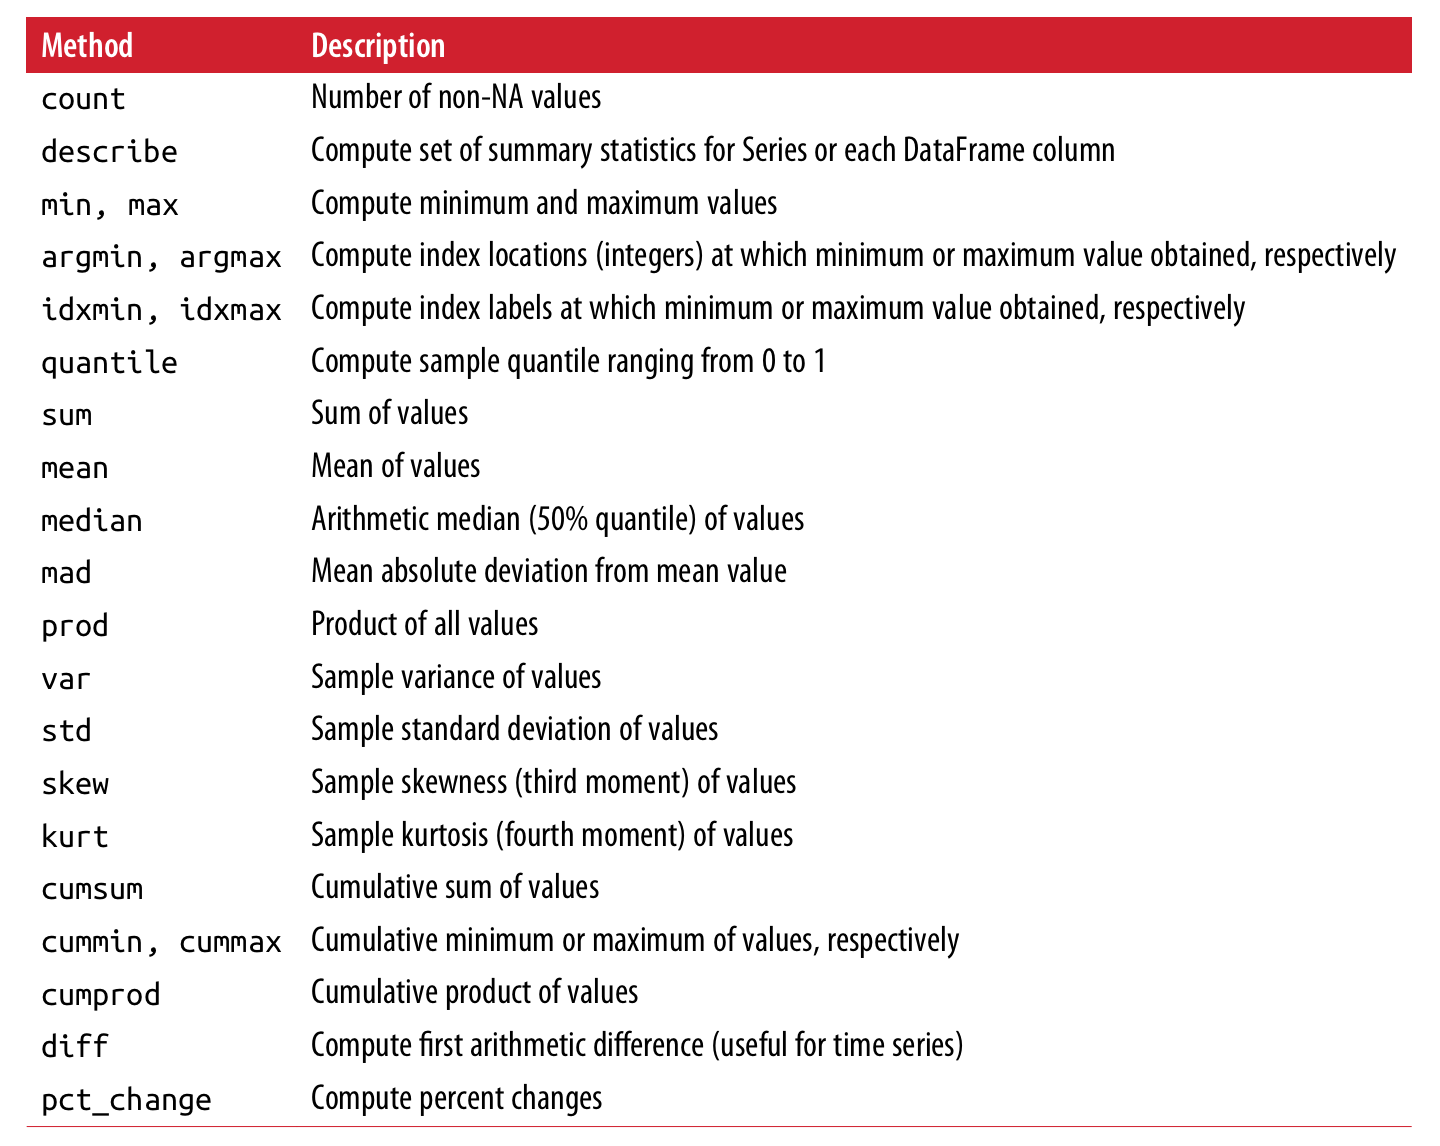
> 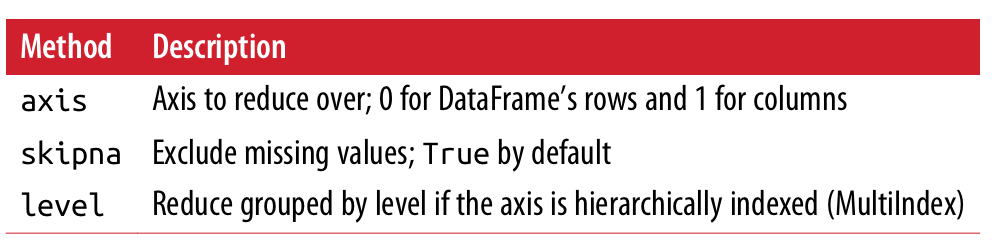

In [3]:
df = pd.DataFrame([[1.4, np.nan], [7.1, -4.5],
                 [np.nan, np.nan], [0.75, -1.3]],
                 index=['a','b','c','d'],
                 columns=['one', 'two'])
df

,one,two
a,1.40,NaN
b,7.10,-4.5
c,NaN,NaN
d,0.75,-1.3


In [4]:
df.mean(axis='columns') # or axis = 1

a    1.400
b    1.300
c      NaN
d   -0.275
dtype: float64

In [6]:
df.mean(axis='columns', skipna=False)

a      NaN
b    1.300
c      NaN
d   -0.275
dtype: float64

In [10]:
df.idxmax()
df.cumsum()
df.describe()

,one,two
count,3.000000,2.000000
mean,3.083333,-2.900000
std,3.493685,2.262742
min,0.750000,-4.500000
25%,1.075000,-3.700000
50%,1.400000,-2.900000
75%,4.250000,-2.100000
max,7.100000,-1.300000


In [13]:
obj = pd.Series(['a','a','b','c']*4)
obj.describe()

count     16
unique     3
top        a
freq       8
dtype: object

- On non-numeric data, *descibe* produces alternative summary statistics:

### Correlation and Covariance

In [3]:
import pandas_datareader.data as web
all_data = {ticker: web.get_data_yahoo(ticker)
           for ticker in ['AAPL','IBM','MSFT','GOOG']}

In [6]:
price = pd.DataFrame({ticker: data['Adj Close']
                     for ticker, data in all_data.items()})
volume = pd.DataFrame({ticker: data['Volume']
                      for ticker, data in all_data.items()})

In [7]:
returns = price.pct_change()
returns.tail()

,AAPL,IBM,MSFT,GOOG
Date,,,,
2022-08-29,-0.013690,-0.000537,-0.010668,-0.008625
2022-08-30,-0.015305,-0.005602,-0.008521,-0.003897
2022-08-31,-0.010635,-0.008721,-0.005704,-0.006915
2022-09-01,0.004707,0.009420,-0.004092,0.012826
2022-09-02,-0.013611,-0.014422,-0.016667,-0.016915


In [12]:
returns.corr() # returns.cov()

,AAPL,IBM,MSFT,GOOG
AAPL,1.000000,0.438293,0.761423,0.686660
IBM,0.438293,1.000000,0.478682,0.446418
MSFT,0.761423,0.478682,1.000000,0.788008
GOOG,0.686660,0.446418,0.788008,1.000000


In [13]:
returns['MSFT'].corr(returns['IBM']) # = returns.MSFT.corr(returns.IBM)

0.4786815338768153

In [15]:
returns.corrwith(returns.IBM)

AAPL    0.438293
IBM     1.000000
MSFT    0.478682
GOOG    0.446418
dtype: float64

### Unique Values, Value Counts, and Membership
- Another class of related methods extracts information about the values contained in a **one-dimenstional Series**.

>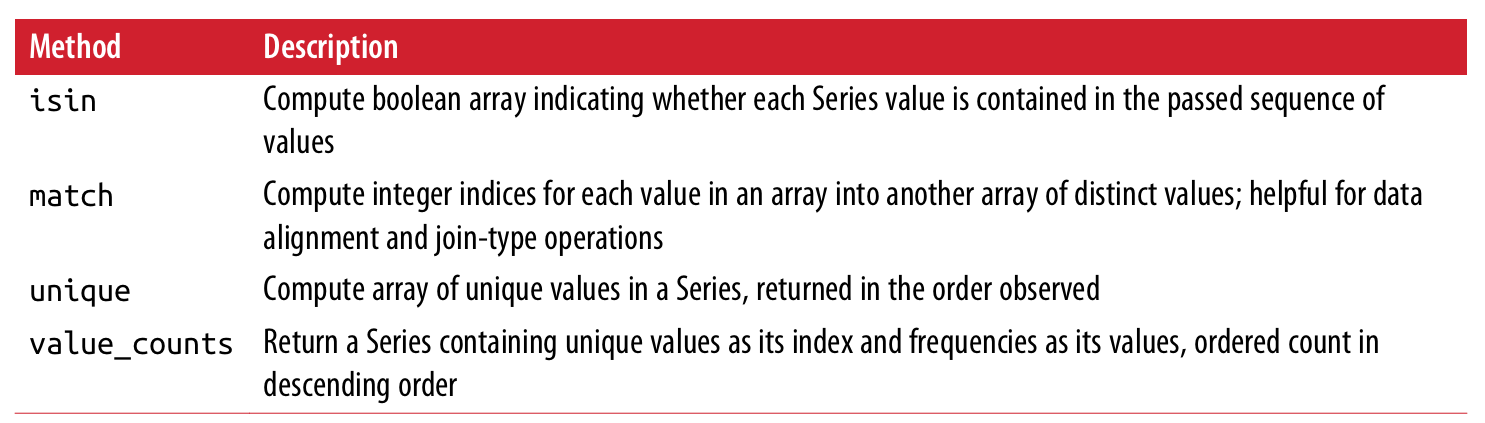

In [4]:
obj = pd.Series(['c','a','d','a','a','b','b','c','c'])
uniques = obj.unique()
uniques

array(['c', 'a', 'd', 'b'], dtype=object)

- ***unique***, which gives you an array of the unique values in **Series**
- The unique values are not necessarily returned in sorted order, but could be sorted after the fact if needed (***uniques.sorted()***

In [5]:
obj.value_counts() # = pd.value_counts(obj.values)

c    3
a    3
b    2
d    1
dtype: int64

- ***value_counts***, which computes a Series containing value frequencies:
- The Series is sorted by value in descending order as a convenience.

In [7]:
mask = obj.isin(['b', 'c'])
mask

0     True
1    False
2    False
3    False
4    False
5     True
6     True
7     True
8     True
dtype: bool

In [8]:
obj[mask]

0    c
5    b
6    b
7    c
8    c
dtype: object

- ***isin*** performs a vectorized set membership check and can be useful in filtering a dataset down to a subset of values in a Series or column in a DataFrame

- the ***Index.get_indexer*** method, which gives you an index array from an array of possibly non-distinct values into another array of distinct values:

In [9]:
to_match = pd.Series(['c','a','b','b','c','a'])
unique_vals = pd.Series(['c','b','a'])
pd.Index(unique_vals).get_indexer(to_match)

array([0, 2, 1, 1, 0, 2])

In [10]:
data = pd.DataFrame({'Qu1':[1,3,4,3,4],
                    'Qu2':[2,3,1,2,3],
                    'Qu3':[1,5,2,4,4,]})
data

,Qu1,Qu2,Qu3
0,1,2,1
1,3,3,5
2,4,1,2
3,3,2,4
4,4,3,4


In [13]:
# Passing "pandas.value_counts" to this DataFrame's "apply" function gives:
result = data.apply(pd.value_counts).fillna(0)
result

,Qu1,Qu2,Qu3
1,1.0,1.0,1.0
2,0.0,2.0,1.0
3,2.0,2.0,0.0
4,2.0,0.0,2.0
5,0.0,0.0,1.0


- Here, the **row labels** in the result are the distict values occuring in all of the columns.
- The **values** are the respective counts of these values in each column.
- 5는 첫번째 열에서 0개 나옴(5행 1열), 1은 2열에서 1번 나옴(1행 2열)